---
title: "Data Cleaning"
format:
    html: 
        code-fold: false
        embed-resources: true
---

{{< include overview.qmd >}} 

{{< include method.qmd >}} 

Below, we will show how you how we cleaned the datasets we used for this project. We cleaned a significant number of datasets. 

### Navigation
- [Go to Accuracy Prediction Section](##Accuracy-Prediction-Cleaning)
- [Go to Reliability Section](##Reliability-Cleaning)
- [Go to Financial Statement Section](##Financial-Statement-Cleaning)
- [Go to Alerts Section](##Alert-Cleaning)
- [Go to RSS Feed Section](##Accuracy-Prediction-Cleaning)

---


If you need a refresher on the data sources, visit the link below:

**[Visit Data Source Information Here](../data-collection/overview.qmd)**

**Import Libraries**: 

In [54]:
import missingno as msno
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from datetime import datetime
import re 


## Accuracy Prediction Cleaning

**Load dataset & View raw version**

In [55]:
#load the "rapid_transit_and_bus_prediction_accuracy_data.csv" file
ride_accuracy = pd.read_csv("../../data/raw-data/rapid_transit_and_bus_prediction_accuracy_data.csv")

#convert csv file into a dataframe
ride_accuracy_df = pd.DataFrame(ride_accuracy)

#print the first 10 rows of dataframe
print(ride_accuracy_df.head(10))

#print shape of dataframe
print(ride_accuracy_df.shape)

       weekly mode route_id        bin arrival_departure  num_predictions  \
0  2020-08-06  bus      NaN    0-3 min         departure           233967   
1  2020-08-06  bus      NaN    3-6 min         departure           227406   
2  2020-08-06  bus      NaN   6-12 min         departure           445848   
3  2020-08-06  bus      NaN  12-30 min         departure          1261843   
4  2020-08-13  bus      NaN    0-3 min         departure           240187   
5  2020-08-13  bus      NaN    3-6 min         departure           233322   
6  2020-08-13  bus      NaN   6-12 min         departure           455828   
7  2020-08-13  bus      NaN  12-30 min         departure          1299411   
8  2020-08-20  bus      NaN    0-3 min         departure           234504   
9  2020-08-20  bus      NaN    3-6 min         departure           227992   

   num_accurate_predictions  
0                    183615  
1                    178297  
2                    368421  
3                   1101363  
4 

**Identify Missing Values**

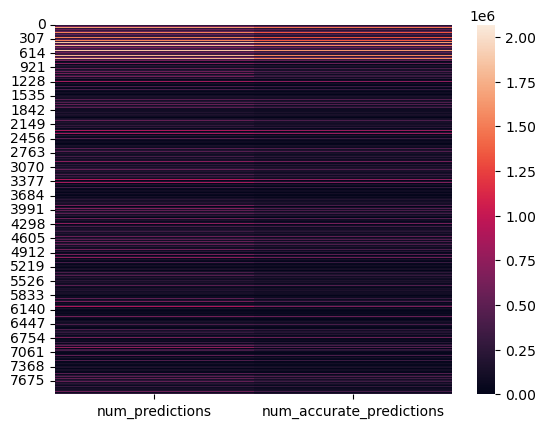

In [56]:
#subset dataframe to create a heatmap to visualize missing data. Keep numeric value columns
ride_accuracy_df_subset = ride_accuracy_df[[ "num_predictions", "num_accurate_predictions" ]]

#create heatmap of datafram before dropping NA values
sns.heatmap(ride_accuracy_df_subset)
plt.show() #show heatmap

**Identifying Outlier**

       num_predictions  num_accurate_predictions
count     7.964000e+03              7.964000e+03
mean      2.411512e+05              1.988910e+05
std       2.944540e+05              2.492383e+05
min       0.000000e+00              0.000000e+00
25%       8.053400e+04              7.106275e+04
50%       1.306255e+05              1.100235e+05
75%       3.003818e+05              2.470378e+05
max       2.070137e+06              1.818970e+06


<Axes: >

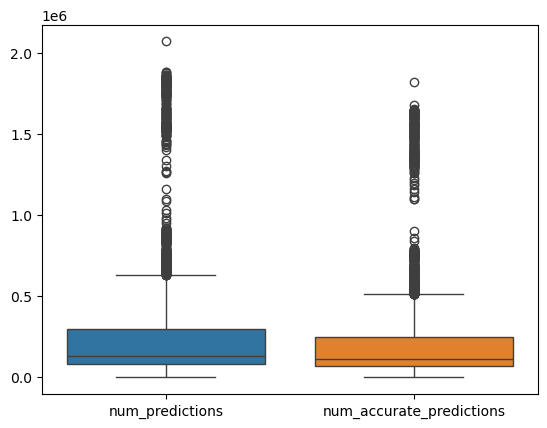

In [57]:
#find outliers before dropping na using describe()
print(ride_accuracy_df.describe())

#create boxplot of dataframe with na to visualize outliers
sns.boxplot(data=ride_accuracy_df)

By looking at this box plot, we found plenty of outliers, which are represented by the outlined circles. As a 

**Handling Null Values**

In [58]:
#find na values in the columns
ride_accuracy_df_na = ride_accuracy_df.isna().sum()
print(ride_accuracy_df_na)

#drop rows with NA values from the route_id column because it is the only column with na values
ride_accuracy_df_dropna = ride_accuracy_df
ride_accuracy_df_dropna.dropna(inplace=True)
print(ride_accuracy_df_dropna.shape)

weekly                        0
mode                          0
route_id                    780
bin                           0
arrival_departure             0
num_predictions               0
num_accurate_predictions      0
dtype: int64
(7184, 7)


**Datatype Transformation**

In [59]:
#check the data types of columns
print("----Data Types Before Transformation-----")
print(ride_accuracy_df_dropna.dtypes)

#convert "weekly" column data type to datetime
ride_accuracy_df_dropna["weekly"] = pd.to_datetime(ride_accuracy_df_dropna["weekly"])
#convert "mode" column data type to string
ride_accuracy_df_dropna["mode"] = ride_accuracy_df_dropna["mode"].astype(str)
#convert "route_id" column data type to string
ride_accuracy_df_dropna["route_id"] = ride_accuracy_df_dropna["route_id"].astype(str)
#convert "bin" column data type to string
ride_accuracy_df_dropna["bin"] = ride_accuracy_df_dropna["bin"].astype(str)
#convert "arrival_departure" column data type to string
ride_accuracy_df_dropna["arrival_departure"] = ride_accuracy_df_dropna["arrival_departure"].astype(str)

#check data types of columns after transformation
print("----Data Types After Transformation-----")
print(ride_accuracy_df_dropna.dtypes)

----Data Types Before Transformation-----
weekly                      object
mode                        object
route_id                    object
bin                         object
arrival_departure           object
num_predictions              int64
num_accurate_predictions     int64
dtype: object
----Data Types After Transformation-----
weekly                      datetime64[ns]
mode                                object
route_id                            object
bin                                 object
arrival_departure                   object
num_predictions                      int64
num_accurate_predictions             int64
dtype: object


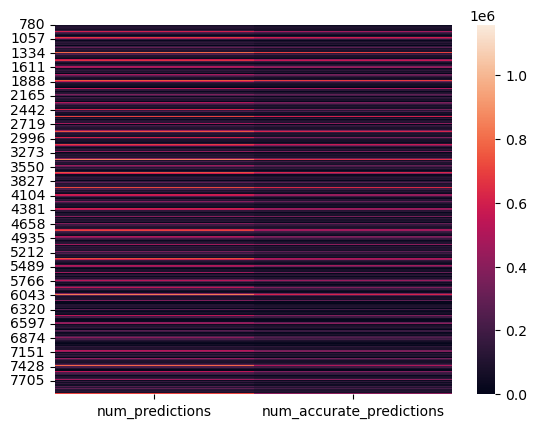

In [60]:
#subset dataframe to create a heatmap to visualize missing data. Keep numeric value columns
ride_accuracy_df_no_na_subset = ride_accuracy_df_dropna[[ "num_predictions", "num_accurate_predictions" ]]

#create heatmap of dataframe after dropping NA values
sns.heatmap(ride_accuracy_df_no_na_subset)
plt.show() #show heatmap

                              weekly  num_predictions  \
count                           7184     7.184000e+03   
mean   2022-09-09 15:45:18.040088832     1.900083e+05   
min              2020-08-03 00:00:00     0.000000e+00   
25%              2021-08-30 00:00:00     7.617800e+04   
50%              2022-09-26 00:00:00     1.199255e+05   
75%              2023-09-25 00:00:00     2.237600e+05   
max              2024-08-26 00:00:00     1.158573e+06   
std                              NaN     1.842277e+05   

       num_accurate_predictions  
count               7184.000000  
mean              154576.004176  
min                    0.000000  
25%                67576.000000  
50%               101258.000000  
75%               187399.250000  
max               904424.000000  
std               144457.231305  


<Axes: >

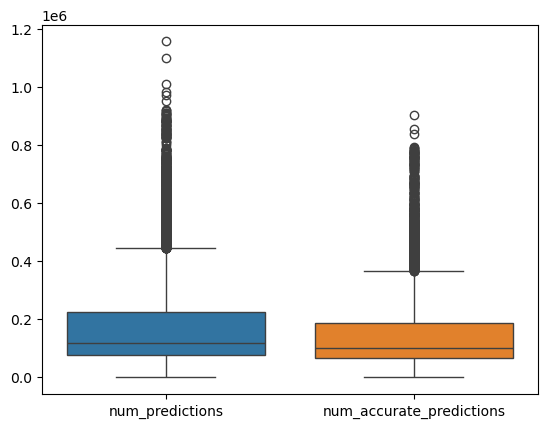

In [61]:
#find outliers after dropping na using describe()
print(ride_accuracy_df_dropna.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=ride_accuracy_df_dropna)

**Cleaning Features**

In [62]:
#split the "bin" column based on space character to separate the numerical range and the min unit
ride_accuracy_df_dropna[["a", "b"]] = ride_accuracy_df_dropna["bin"].str.split(" ", expand = True)
print(ride_accuracy_df_dropna.head())

#split the "a" column based on the "-" character to get a low range and high range of the bin values
ride_accuracy_df_dropna[["Low Range Bin Time (min)", "High Range Bin Time (min)"]] = ride_accuracy_df_dropna["a"].str.split("-", expand = True)
print(ride_accuracy_df_dropna.head())

#remove the unneeded "a" and "b" columns
ride_accuracy_df_drop_cols = ride_accuracy_df_dropna
ride_accuracy_df_drop_cols = ride_accuracy_df_drop_cols.drop(['a', 'b'], axis=1)
print(ride_accuracy_df_drop_cols.head(10))

        weekly    mode route_id        bin arrival_departure  num_predictions  \
780 2020-08-03  subway     Blue    0-3 min           blended            63612   
781 2020-08-03  subway     Blue    3-6 min           blended            65346   
782 2020-08-03  subway     Blue   6-12 min           blended           124158   
783 2020-08-03  subway     Blue  12-30 min           blended           350575   
784 2020-08-03  subway  Green-B    0-3 min           blended           144067   

     num_accurate_predictions      a    b  
780                     58116    0-3  min  
781                     58809    3-6  min  
782                    112668   6-12  min  
783                    314248  12-30  min  
784                    117550    0-3  min  
        weekly    mode route_id        bin arrival_departure  num_predictions  \
780 2020-08-03  subway     Blue    0-3 min           blended            63612   
781 2020-08-03  subway     Blue    3-6 min           blended            65346   
782 20

**Export Cleaned Sheet**

In [63]:
ride_accuracy_df_drop_cols.to_csv("../../data/processed-data/Clean_Ride_Accuracy.csv")

**Transforming to Binary** 

In [64]:
#alternative analysis: add a column to the dataframe for binary classification target
ride_accuracy_df_binary = ride_accuracy_df_drop_cols

print(ride_accuracy_df_binary["weekly"].dtype) #check id column is datatime type

#we want to observe all dates after 2022-01-01 as "1"'s and all dates before 2022-01-01 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began
date_to_string = "2022-01-01" #set variable to 2022-01-01 to find its numeric format
date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
print(type(date_convert)) #check if it is datetime format
num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
print(num_date) #print the numeric conversion of the 2022-01-01 date which equals 1641013200, easier for if else statement to transform dates into binary values


ride_accuracy_df_binary["Pre and Post 2021"] = ride_accuracy_df_binary["weekly"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(ride_accuracy_df_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

ride_accuracy_df_binary["Pre and Post 2021 Binary"] = np.where(ride_accuracy_df_binary["Pre and Post 2021"] > 1641013200, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(ride_accuracy_df_binary["Pre and Post 2021 Binary"].head()) #print first few rows of binary dates


datetime64[ns]
<class 'datetime.datetime'>
1641013200
780    1596412800
781    1596412800
782    1596412800
783    1596412800
784    1596412800
Name: Pre and Post 2021, dtype: int64
780    0
781    0
782    0
783    0
784    0
Name: Pre and Post 2021 Binary, dtype: int64


In [65]:
#export clean binary data csv file to processed-data folder
ride_accuracy_df_binary.to_csv("../../data/processed-data/Clean_Ride_Accuracy_Binary.csv")

## Reliability Cleaning

In [66]:
ride_reliability = pd.read_csv("../../data/raw-data/MBTA_The_RIDE_Reliability.csv")

#convert csv file into a dataframe
ride_reliability_df = pd.DataFrame(ride_reliability)

#print the first 10 rows of dataframe
print(ride_reliability_df.head(10))

#print shape of dataframe
print(ride_reliability_df.shape)

                trip_date  ontime_trip_count  trip_count  ObjectId
0  2014/07/01 04:00:00+00               5479        5884         1
1  2014/07/02 04:00:00+00               5297        5612         2
2  2014/07/03 04:00:00+00               4959        5306         3
3  2014/07/04 04:00:00+00               1530        1558         4
4  2014/07/05 04:00:00+00               2420        2580         5
5  2014/07/06 04:00:00+00               2202        2369         6
6  2014/07/07 04:00:00+00               5048        5332         7
7  2014/07/08 04:00:00+00               5492        5925         8
8  2014/07/09 04:00:00+00               5668        6163         9
9  2014/07/10 04:00:00+00               5487        6027        10
(3681, 4)


In [67]:
#find na values in the columns
ride_reliability_df_na = ride_reliability_df.isna().sum()
print(ride_reliability_df_na) #no NA values in the dataframe

trip_date            0
ontime_trip_count    0
trip_count           0
ObjectId             0
dtype: int64


In [68]:
print(type(ride_reliability_df))
print(ride_reliability_df["trip_date"].dtypes)
print(ride_reliability_df["ontime_trip_count"].dtypes)
print(ride_reliability_df["trip_count"].dtypes)
print(ride_reliability_df["ObjectId"].dtypes)


#convert the "trip_date" column to string data type to prepare for splitting
ride_reliability_df["trip_date"] = ride_reliability_df["trip_date"].astype(str)

print("After converting to string type: ", ride_reliability_df["trip_date"].dtypes)

<class 'pandas.core.frame.DataFrame'>
object
int64
int64
int64
After converting to string type:  object


In [69]:
#split the "trip_date" column based on space to separate date and time
ride_reliability_df[["Date", "Time"]] = ride_reliability_df["trip_date"].str.split(" ", expand = True)
print(ride_reliability_df.head())

#convert "Date" column to YYYY-MM-DD date format to match the column in the cleaned Clean_Ride_Accuracy.csv file
ride_reliability_df["Date"] = pd.to_datetime(ride_reliability_df["Date"]) #convert "Date" column to dateime format

ride_reliability_df["Date"] = ride_reliability_df["Date"].dt.strftime('%Y-%m-%d') #reformat "Date" value as yyyy-mm-dd

print(ride_reliability_df["Date"].head()) #print first few rows of reformatted Date column

                trip_date  ontime_trip_count  trip_count  ObjectId  \
0  2014/07/01 04:00:00+00               5479        5884         1   
1  2014/07/02 04:00:00+00               5297        5612         2   
2  2014/07/03 04:00:00+00               4959        5306         3   
3  2014/07/04 04:00:00+00               1530        1558         4   
4  2014/07/05 04:00:00+00               2420        2580         5   

         Date         Time  
0  2014/07/01  04:00:00+00  
1  2014/07/02  04:00:00+00  
2  2014/07/03  04:00:00+00  
3  2014/07/04  04:00:00+00  
4  2014/07/05  04:00:00+00  
0    2014-07-01
1    2014-07-02
2    2014-07-03
3    2014-07-04
4    2014-07-05
Name: Date, dtype: object


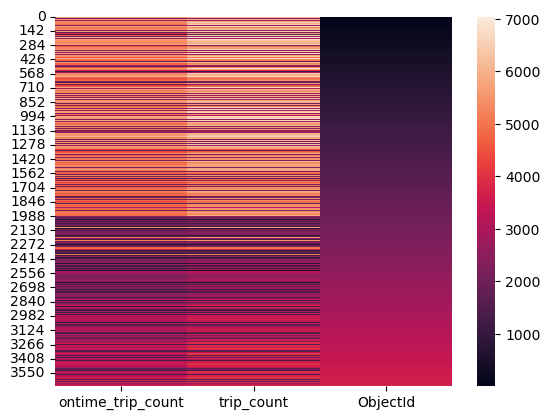

In [70]:
#subset dataframe to create a heatmap to visualize missing data - even though there are no missing data. Keep numeric value columns
ride_reliability_df_subset = ride_reliability_df[[ "ontime_trip_count", "trip_count", "ObjectId"]]

#create heatmap of dataframe, no NA values, no NA values needed to drop
sns.heatmap(ride_reliability_df_subset)
plt.show() #show heatmap

       ontime_trip_count   trip_count     ObjectId
count        3681.000000  3681.000000  3681.000000
mean         3349.814453  3730.092910  1841.000000
std          1541.218043  1759.167967  1062.757498
min           150.000000   163.000000     1.000000
25%          2190.000000  2353.000000   921.000000
50%          3005.000000  3362.000000  1841.000000
75%          4943.000000  5529.000000  2761.000000
max          6181.000000  7045.000000  3681.000000


<Axes: >

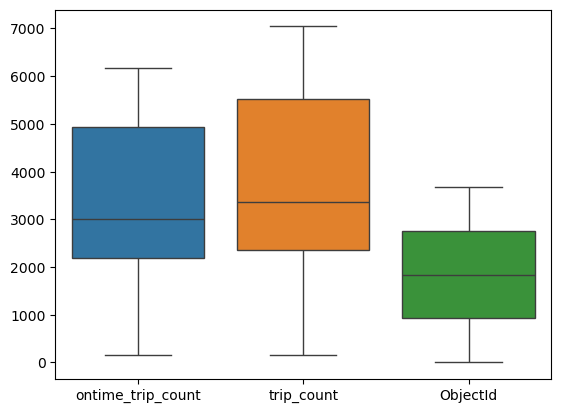

In [71]:
#find outliers using describe()
print(ride_reliability_df.describe())

#create boxplot of dataframe to visualize outliers
sns.boxplot(data=ride_reliability_df)

In [72]:
#export clean csv file to processed-data folder
ride_reliability_df.to_csv("../../data/processed-data/Clean_Ride_Reliability.csv")

## Alert Cleaning 

In [73]:
# Load the dataset
file_path = '../../data/raw-data/merged_alerts.csv'  # Replace with your file's actual path

merged_alerts = pd.read_csv(file_path)
print(merged_alerts.head())
shape = merged_alerts.shape
print(shape)
data_types = merged_alerts.dtypes
print(data_types)


/var/folders/wx/8tzhq3ln59j92r3pl8v47rfw0000gn/T/ipykernel_83572/1200944873.py:4: DtypeWarning: Columns (16,25) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_alerts = pd.read_csv(file_path)


   alert_id        cause cause_detail  effect effect_detail severity_level  \
0    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
1    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
2    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
3    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
4    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   

   severity                                             header description  \
0         7  Route 117 inbound trips all day on Saturdays a...         NaN   
1         7  Route 117 inbound trips all day on Saturdays a...         NaN   
2         7  Route 117 inbound trips all day on Saturdays a...         NaN   
3         7  Route 117 inbound trips all day on Saturdays a...         NaN   
4         7  Route 117 inbound trips all day on Saturdays a...         NaN   

  alert_lifecycle  ... active_period_start_dt  active_period_e

**Handle Null Values** 

    - visualize null 
    - evaluate if columns with many null are essential or can be ommitted


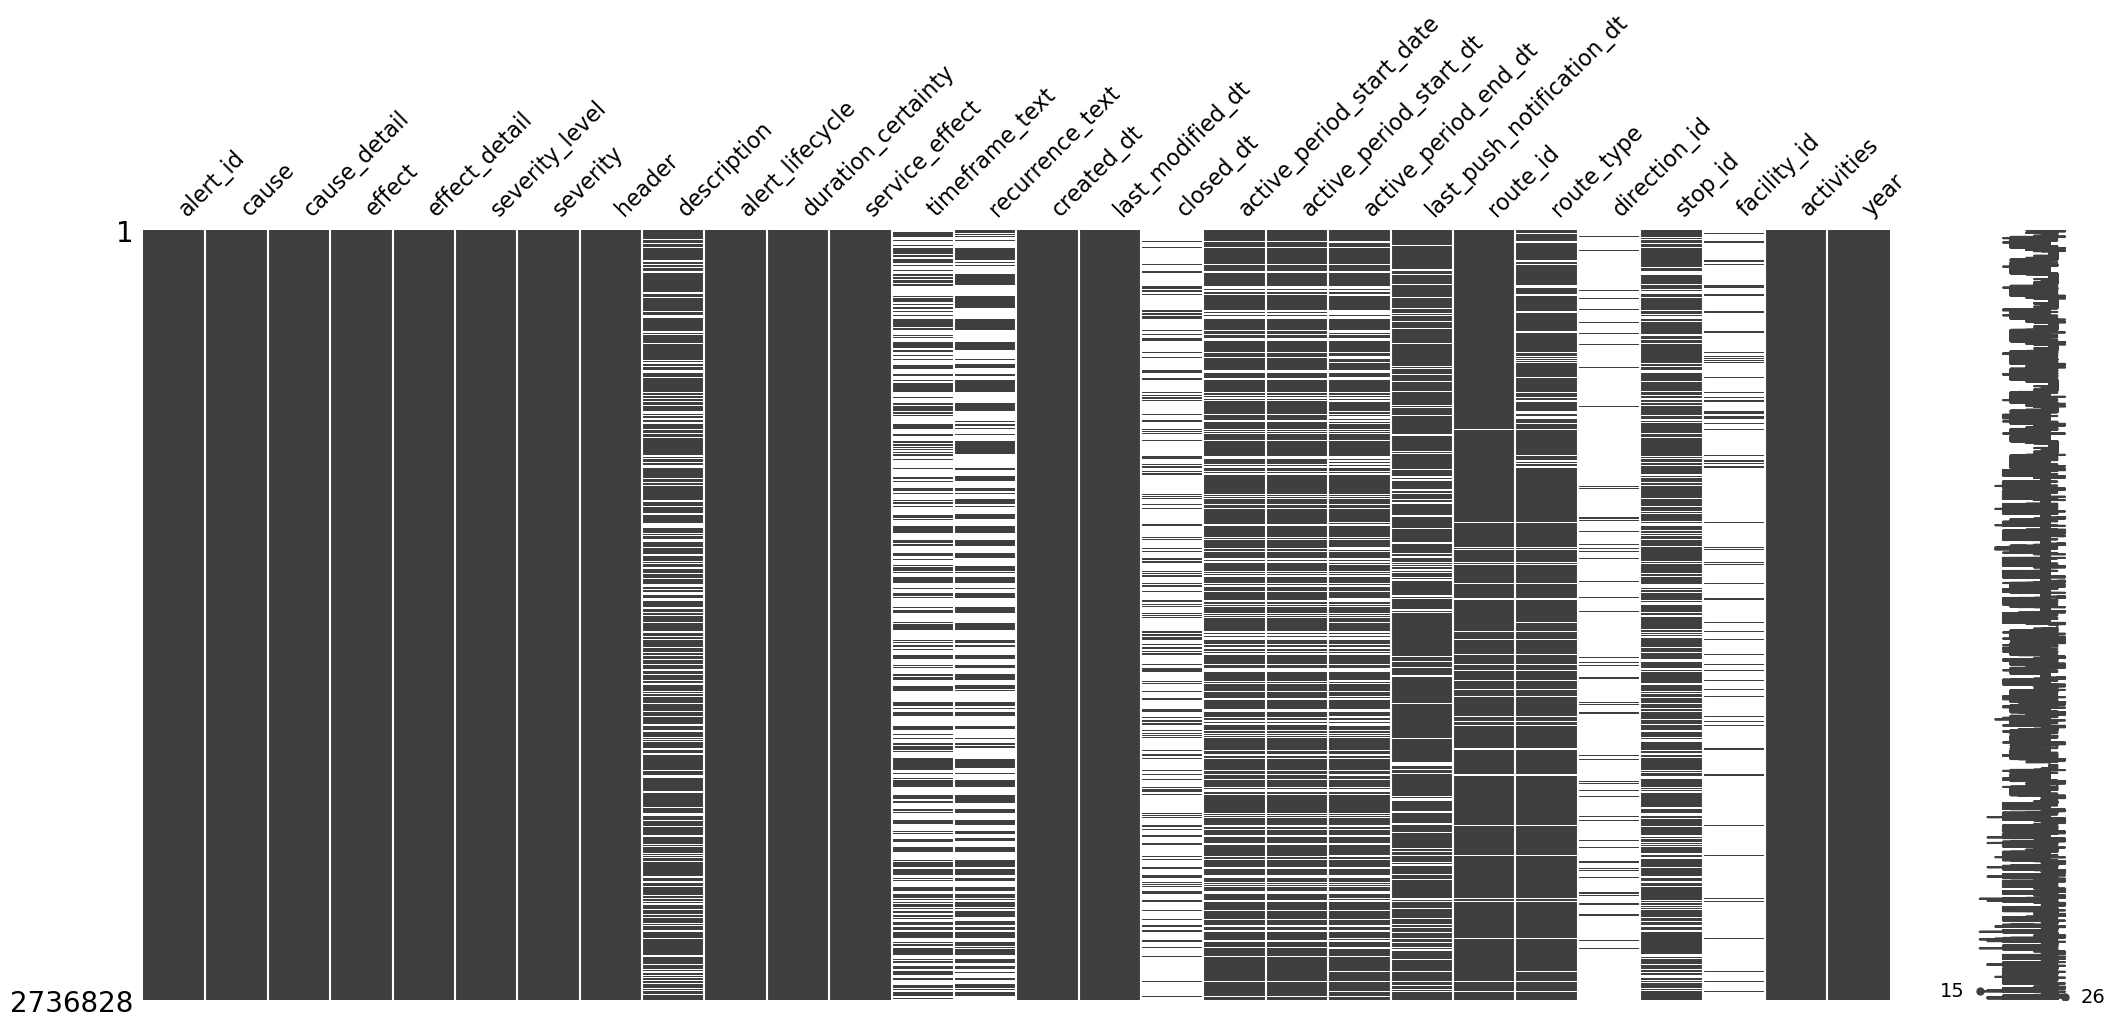

In [74]:
msno.matrix(merged_alerts) # visualized it as a matrix 
plt.show()

In [75]:
missing_values_count = merged_alerts.isnull().sum()
print(missing_values_count)

alert_id                           0
cause                              0
cause_detail                       0
effect                             0
effect_detail                      0
severity_level                     0
severity                           0
header                             0
description                   604174
alert_lifecycle                  683
duration_certainty                 0
service_effect                   371
timeframe_text               1620140
recurrence_text              1495277
created_dt                         0
last_modified_dt                   0
closed_dt                    2168374
active_period_start_date      570060
active_period_start_dt        570060
active_period_end_dt          686506
last_push_notification_dt     417188
route_id                      108719
route_type                    225809
direction_id                 2489627
stop_id                       594191
facility_id                  2511076
activities                        47
y


The following are features with high missing values: 
- `description` (604,174 missing)
- `timeframe_text` (1,620,140 missing)
- `recurrence_text` (1,495,277 missing)
- `closed_dt` (2,168,374 missing)
- `direction_id` (2,489,627 missing)
- `facility_id` (2,511,076 missing)

---

These columns have substantial missing values. However, some of these columns are critical to understanding lifecycle events.

**Critical Columns Contextually**
- `description`: Shows what stops are affected, inbound/outbound.  
- `recurrence_text`: Explains what dates are affected. However, over 1 million are missing, which is a significantly high null, so I will remove this column. 

---

**Non-Essential Columns**
- `timeframe_text`  
- `closed_dt`  
- `direction_id`  
- `facility_id`  

---

**Contextually Unneeded Columns**
- `alert_id`  
- `header`  
- `alert_lifecycle`  
- `duration_certainty`  
- `created_dt`  
- `last_modified_dt`  
- `closed_dt`  
- `active_period_start_dt`  
- `active_period_end_dt`  
- `last_push_notification_dt`  
- `service_effect`  
- `direction_id`  
- `stop_id`  
- `facility_id`  

---

**Necessary Columns**
- `cause`: Cause of the alert.  
- `cause_detail`: Description of the alert.  
- `effect`: The effect of the alert on the affected entity.  
- `effect_detail`: Description of the effect.  
- `severity_level`: Severity level of the alert, expressed as a categorical value.  
- `severity`: Numeric severity (0 to 10).  
- `description`: Shows stops and routes affected.  
- `route_id`: Shows the specific stop affected.  
- `route_type`: Shows the type of route affected.


In [76]:

# Check for missing values and their distribution
missing_values = merged_alerts.isnull().sum()

# Display basic statistics for numeric columns
numeric_stats = merged_alerts.describe()

# Display basic statistics for categorical columns
categorical_columns = merged_alerts.select_dtypes(include=['object'])
categorical_stats = categorical_columns.describe()


In [77]:
# Columns to drop
columns_to_drop = [
    'alert_id',                
    'duration_certainty',     
    'recurrence_text',         
    'created_dt',              
    'last_modified_dt',       
    'closed_dt',              
    'active_period_start_date', 
    'active_period_start_dt',
    'active_period_end_dt',    
    'last_push_notification_dt', 
    'direction_id',            
    'facility_id',             
    'timeframe_text',
    'route_type',
    'stop_id',
    'service_effect',
    'alert_lifecycle',
    'activities',
    'header'
]

# Drop the irrelevant columns
merged_alerts_cleaned = merged_alerts.drop(columns=columns_to_drop, errors='ignore')

# Impute Blank Descriptions with unknown
merged_alerts_cleaned['description'].fillna('Unknown', inplace=True)

# For 'route_id', fill missing with "Unspecified"
merged_alerts_cleaned['route_id'].fillna('Unspecified', inplace=True)

# Display results after cleaning
print(f"Remaining columns: {merged_alerts_cleaned.columns.tolist()}")
print(f"Shape after cleaning: {merged_alerts_cleaned.shape}")
print(f"Missing values after cleaning: \n{merged_alerts_cleaned.isnull().sum()}")
print(merged_alerts_cleaned.head(5))

Remaining columns: ['cause', 'cause_detail', 'effect', 'effect_detail', 'severity_level', 'severity', 'description', 'route_id', 'year']
Shape after cleaning: (2736828, 9)
Missing values after cleaning: 
cause             0
cause_detail      0
effect            0
effect_detail     0
severity_level    0
severity          0
description       0
route_id          0
year              0
dtype: int64
         cause cause_detail  effect effect_detail severity_level  severity  \
0  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
1  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
2  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
3  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
4  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   

  description route_id  year  
0     Unknown      117  2024  
1     Unknown      117  2024  
2     Unknown      117  2024  
3     Unkn

In [78]:
# Output basic statistics after cleaning
print("Numeric Statistics:")
print(merged_alerts_cleaned.describe())

print("Categorical Statistics:")
categorical_columns_cleaned = merged_alerts_cleaned.select_dtypes(include=['object'])
print(categorical_columns_cleaned.describe())

Numeric Statistics:
           severity          year
count  2.736828e+06  2.736828e+06
mean   3.752940e+00  2.022461e+03
std    3.155161e+00  1.364026e+00
min    0.000000e+00  2.020000e+03
25%    1.000000e+00  2.021000e+03
50%    3.000000e+00  2.023000e+03
75%    7.000000e+00  2.024000e+03
max    1.000000e+01  2.024000e+03
Categorical Statistics:
                cause   cause_detail        effect effect_detail  \
count         2736828        2736828       2736828       2736828   
unique             11             43             8            25   
top     UNKNOWN_CAUSE  UNKNOWN_CAUSE  OTHER_EFFECT         DELAY   
freq          1173449        1173449       1200557        897785   

       severity_level description      route_id  
count         2736828     2736828       2736828  
unique              3       13461           417  
top            SEVERE     Unknown  CR-Worcester  
freq          1117158      604174        288912  


**Standarize Values** 

**Thoughts on Handling Outlier** 

Severity is the only value that should be looked at for outliers. However, we must think about the severity outliers representing real world events, that is severity values indicate MAJOR disruption (with grave consequences like death or injury). These should not be removed, since they provide valuable information about performance. Outliers should only be removd if there are data-entry errors. 

Because we are keeping the outliers, we should analyze to understand the distribution of outlier data. Below is a box plot, which displays the distribution of outliers. 

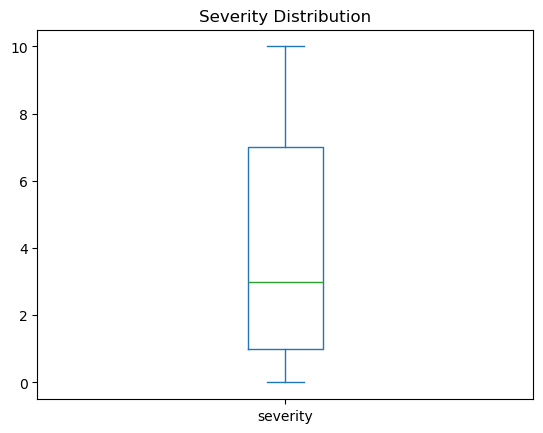

In [79]:
merged_alerts_cleaned['severity'].plot(kind='box', title='Severity Distribution')
plt.show()

**Thoughts**: The whiskers extend to the minimum and maximum values within 1.5 times the IQR. Therefore, there are no points outside the whiskers, indicating that all the values for severity fall within the expected range of 0–10. We will expand more on the alerts in the EDA section. 

**Extracting Affected Direction and Stops from Description** 

In [80]:
def extract_direction(description):
    if "Affected direction:" in description:
        try:
            return description.split("Affected direction:")[1].split("\n")[0].strip()
        except IndexError:
            return None
    return None

def extract_stops(description):
    if "Affected stops:" in description:
        try:
            stops = description.split("Affected stops:")[1].replace("\r", "").strip().split("\n")
            # Deduplicate stops
            stops = list(set([stop.strip() for stop in stops if stop.strip()]))
            return stops
        except IndexError:
            return None
    return None

merged_alerts_cleaned['affected_direction'] = merged_alerts_cleaned['description'].apply(extract_direction)
merged_alerts_cleaned['affected_stops'] = merged_alerts_cleaned['description'].apply(extract_stops)

print(merged_alerts_cleaned[['description', 'affected_direction', 'affected_stops']].head())

# Count rows where 'affected_direction' and 'affected_stops' are not None or NaN
affected_direction_count = merged_alerts_cleaned['affected_direction'].notna().sum()
affected_stops_count = merged_alerts_cleaned['affected_stops'].notna().sum()
description_count = (merged_alerts_cleaned['description'] != "Unknown").sum()


# Print the results
print(f"Number of rows with description as known: {description_count}")
print(f"Number of rows with values in 'affected_direction' (not 'None'): {affected_direction_count}")
print(f"Number of rows with values in 'affected_stops' (not 'None'): {affected_stops_count}")



  description affected_direction affected_stops
0     Unknown               None           None
1     Unknown               None           None
2     Unknown               None           None
3     Unknown               None           None
4     Unknown               None           None
Number of rows with description as known: 2132654
Number of rows with values in 'affected_direction' (not 'None'): 680508
Number of rows with values in 'affected_stops' (not 'None'): 1362444


**Clean texts** 

In [81]:
# Function to clean text
def clean_text(text):
    if pd.isna(text):  # Check for NaN
        return None
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    text = re.sub(r'_', ' ', text)  # Replace underscores with spaces
    return text

# Cleaning each column explicitly
merged_alerts_cleaned['cause'] = merged_alerts_cleaned['cause'].apply(clean_text)
merged_alerts_cleaned['cause_detail'] = merged_alerts_cleaned['cause_detail'].apply(clean_text)
merged_alerts_cleaned['effect'] = merged_alerts_cleaned['effect'].apply(clean_text)
merged_alerts_cleaned['effect_detail'] = merged_alerts_cleaned['effect_detail'].apply(clean_text)


print(merged_alerts_cleaned.head(5))



         cause cause_detail  effect effect_detail severity_level  severity  \
0  maintenance  maintenance  detour        detour         SEVERE         7   
1  maintenance  maintenance  detour        detour         SEVERE         7   
2  maintenance  maintenance  detour        detour         SEVERE         7   
3  maintenance  maintenance  detour        detour         SEVERE         7   
4  maintenance  maintenance  detour        detour         SEVERE         7   

  description route_id  year affected_direction affected_stops  
0     Unknown      117  2024               None           None  
1     Unknown      117  2024               None           None  
2     Unknown      117  2024               None           None  
3     Unknown      117  2024               None           None  
4     Unknown      117  2024               None           None  


In [82]:
output_file_path = '../../data/processed-data/processed_alerts.csv'
merged_alerts_cleaned.to_csv(output_file_path, index=False)

print(f"Cleaned data successfully saved to: {output_file_path}")


Cleaned data successfully saved to: ../../data/processed-data/processed_alerts.csv


## News Cleaning 

- pull titles, dates, and sources
- insert stopwords 
- sentiment analysis 
- word cloud 

In [83]:
import json

def extract_news_to_csv(json_file_path, output_csv_path):
    try:
        # Load the JSON data
        with open(json_file_path, 'r') as file:
            data = json.load(file)

        # Extract relevant fields
        simplified_news = []
        for news in data:
            simplified_news.append({
                "title": news.get("title", "N/A"),
                "date": news.get("date", "N/A"),
                "source_name": news.get("source", {}).get("name", "N/A"),
            })

        # Convert to a pandas DataFrame
        news_df = pd.DataFrame(simplified_news)

        # Save to a CSV file
        news_df.to_csv(output_csv_path, index=False)
        print(f"CSV file successfully saved to: {output_csv_path}")

    except FileNotFoundError:
        print(f"File not found: {json_file_path}")
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {json_file_path}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


json_file_path = "../../data/raw-data/google_news_results.json"  
output_csv_path = "../../data/raw-data/google_news_revised.csv" 

extract_news_to_csv(json_file_path, output_csv_path)



CSV file successfully saved to: ../../data/raw-data/google_news_revised.csv


**Clean up datetime**

In [84]:
from datetime import datetime
def clean_date(time):
    # Parse the datetime string
    parsed_date = datetime.strptime(time.split(",")[0], "%m/%d/%Y")
    # Format back to just the date
    return parsed_date.strftime("%m/%d/%Y")

news_csv = pd.read_csv("../../data/raw-data/google_news_revised.csv")

news_csv['cleaned_date'] = news_csv['date'].apply(clean_date)
print(news_csv[['date', 'cleaned_date']].head())


                              date cleaned_date
0  12/16/2024, 01:52 AM, +0000 UTC   12/16/2024
1  12/16/2024, 03:25 AM, +0000 UTC   12/16/2024
2  12/15/2024, 07:18 PM, +0000 UTC   12/15/2024
3  12/13/2024, 05:12 PM, +0000 UTC   12/13/2024
4  12/13/2024, 12:28 AM, +0000 UTC   12/13/2024


In [85]:
news_csv['title'] = news_csv['title'].apply(clean_text)

output_file_path = '../../data/processed-data/processed_news.csv'
news_csv.to_csv(output_file_path, index=False)

print(f"Cleaned data successfully saved to: {output_file_path}")


Cleaned data successfully saved to: ../../data/processed-data/processed_news.csv


## Financial Statement Cleaning

In [89]:
#attempt worked correctly with camelot library function
#import camelot library for table extraction from pdf
import camelot

#set pdf file path
pdf_file = "../../data/raw-data/financial-statement-fy2023.pdf"

#extract table from pdf on page 9 using 'stream" because table data has no border
tables = camelot.read_pdf(pdf_file, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if tables:
    df = tables[0].df
    print(df)
else:
    print("no tables found")

                                                    0  1            2  \
0                                                                       
1                                                                2023   
2                                  Operating revenue:                   
3                         Revenue from transportation  $      376,357   
4                                               Other          76,616   
5                            Total operating revenues         452,973   
6                                 Operating expenses:                   
7                             Transportation services         822,671   
8                            Other operating expenses         968,312   
9    Total operating expenses, excluding depreciation       1,790,983   
10                      Depreciation and amortization         562,247   
11  Total operating expenses, including depreciati...                   
12                                       amortizati

In [ ]:
#drop unneeded columns from the df dataframe. Drop columns with default headers 1 and 3
df.drop([1,3], axis=1, inplace=True)
#print(df) #print dataframe to check columns dropped


In [ ]:
#drop unneeded rows with indexes 0,1, and 2
df.drop([0,1,2], inplace=True)
#print(df)

In [ ]:
#rename headers in dataframe
df.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 2:"June 30, 2023", 4:"June 30, 2022"}, inplace=True)
print(df)

In [ ]:
#rename some values in the "Statements of Revenue, Expenses and Changes in Net Position" column because the table was formatted with too much space for those cells
df.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other revenue"
df.at[12,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
#print(df)

In [ ]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
df.drop([6,11], inplace=True)
print(df)

In [ ]:
#check the data types of columns in the dataframe
print(df.dtypes)
df["Statements of Revenue, Expenses and Changes in Net Position"] = df["Statements of Revenue, Expenses and Changes in Net Position"].astype(str) #transform data type from objects into strings in this column

df["June 30, 2023"] = df["June 30, 2023"].str.replace(",", "") #remove comma characters in column "June 30, 2023"
df["June 30, 2022"] = df["June 30, 2022"].str.replace(",", "") #remove comma characters in column "June 30, 2022"

df["June 30, 2023"] = df["June 30, 2023"].str.replace("(", "") #remove '(' characters in column "June 30, 2023"
df["June 30, 2023"] = df["June 30, 2023"].str.replace(")", "") #remove ')' characters in column "June 30, 2023"

df["June 30, 2022"] = df["June 30, 2022"].str.replace("(", "") #remove '(' characters in column "June 30, 2022"
df["June 30, 2022"] = df["June 30, 2022"].str.replace(")", "") #remove ')' characters in column "June 30, 2022"


df["June 30, 2023"] = df["June 30, 2023"].astype(int) #convert "June 30, 2023" column data type to numeric
df["June 30, 2022"] = df["June 30, 2022"].astype(int) #convert "June 30, 2022" column data type to numeric

print("After conversion", df.dtypes)
print(df)

In [ ]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
df_subset = df[["June 30, 2023", "June 30, 2022"]]

#create heatmap of dataframe
sns.heatmap(df_subset)
plt.show() #show heatmap

In [ ]:
#find outliers in dataframe using describe()
print(df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=df)

In [ ]:
#export budget 2023 net positions data csv file to processed-data folder
df.to_csv("../../data/processed-data/Budget2023_net_positions.csv")

In [ ]:
#revenue_pdf_file = "../../data/raw-data/financial-statement-fy2023.pdf"

#extract revenue table from page 10 of the pdf file
revenue_table23 = camelot.read_pdf(pdf_file, flavor='stream', pages='10')

#if it is a table, then extract the second table from page 10
if revenue_table23:
    revenue23_df = revenue_table23[1].df
    print(revenue23_df)
else:
    print("no tables found")

In [ ]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
revenue23_df.drop(1, axis=1, inplace=True)
#print(revenue23_df) #print dataframe to check columns dropped

In [ ]:
#rename column headers in dataframe
revenue23_df.rename(columns={0:"Sources of Operating Revenue", 2:"June 30, 2023 Revenue", 3:"2023 Percent of Total Operating Revenue", 4:"June 30, 2022 Revenue", 5:"2022 Percent of Total Operating Revenue"}, inplace=True)
#print(revenue23_df)

In [ ]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
revenue23_df.drop([0,1,2], inplace=True)
print(revenue23_df)

In [ ]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
revenue23_df.at[8,"Sources of Operating Revenue"] = "Total Operating Revenue"
print(revenue23_df)


In [ ]:
#strip white spaces, $ and % characters from values in the dataframe
revenue23_df["2023 Percent of Total Operating Revenue"] = revenue23_df["2023 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")
revenue23_df["2022 Percent of Total Operating Revenue"] = revenue23_df["2022 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")

revenue23_df["June 30, 2023 Revenue"] = revenue23_df["June 30, 2023 Revenue"].str.strip().str.replace(",", "")
revenue23_df["June 30, 2022 Revenue"] = revenue23_df["June 30, 2022 Revenue"].str.strip().str.replace(",", "")

print(revenue23_df)

### stop here for now 

In [ ]:
print(revenue23_df.dtypes) #print the data types of columns in dataframe

revenue23_df["Sources of Operating Revenue"] = revenue23_df["Sources of Operating Revenue"].astype(str)
revenue23_df["June 30, 2023 Revenue"] = revenue23_df["June 30, 2023 Revenue"].astype(int)
revenue23_df["2023 Percent of Total Operating Revenue"] = revenue23_df["2023 Percent of Total Operating Revenue"].astype(int)
revenue23_df["June 30, 2022 Revenue"] = revenue23_df["June 30, 2022 Revenue"].astype(int)
revenue23_df["2022 Percent of Total Operating Revenue"] = revenue23_df["2022 Percent of Total Operating Revenue"].astype(int)

print("After data type conversion", revenue23_df.dtypes)


In [ ]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
revenue23_df_subset = revenue23_df[[ "June 30, 2023 Revenue", "2023 Percent of Total Operating Revenue", "June 30, 2022 Revenue", "2022 Percent of Total Operating Revenue"]]

#create heatmap of dataframe
sns.heatmap(revenue23_df_subset)
plt.show() #show heatmap

In [ ]:
#find outliers in dataframe using describe()
print(revenue23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=revenue23_df)

In [ ]:
#export cleaned 2023 operating revenue dataframe in csv file
revenue23_df.to_csv("../../data/processed-data/Budget2023_operating_revenue.csv")

In [ ]:
#extract expenses table from pdf on page 11 using 'stream" because table data has no border
expenses_table = camelot.read_pdf(pdf_file, flavor='stream', pages='11')

#if it is a table and table is found, then extract table and convert the table into a dataframe
if expenses_table :
    expenses23_df = expenses_table[0].df
    print(expenses23_df)
else:
    print("no tables found")

In [ ]:
#drop unneeded columns from the dataframe. Drop columns with default header 1
expenses23_df.drop(1, axis=1, inplace=True)
#print(expenses23_df) #print dataframe to check columns dropped

In [ ]:
#rename column headers in dataframe
expenses23_df.rename(columns={0:"Sources of Operating Expenses", 2:"June 30, 2023 Expenses", 3:"2023 Percent of Total Operating Expenses", 4:"June 30, 2022 Expenses", 5:"2022 Percent of Total Operating Expenses"}, inplace=True)
#print(expenses23_df)

In [ ]:
#drop rows indexes 0,1,2 because they had blank values and other rows were correctly renamed
expenses23_df.drop([0,1,2], inplace=True)
#print(expenses23_df)

In [ ]:
#rename total value column "Sources of Operating Expenses" because the table was missing a label for the total operating expenses at bottom of dataframe
expenses23_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"
#print(expenses23_df)

In [ ]:
#strip white spaces, $ and % characters from values in the dataframe
expenses23_df["2023 Percent of Total Operating Expenses"] = expenses23_df["2023 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")
expenses23_df["2022 Percent of Total Operating Expenses"] = expenses23_df["2022 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")

expenses23_df["June 30, 2023 Expenses"] = expenses23_df["June 30, 2023 Expenses"].str.strip().str.replace(",", "")
expenses23_df["June 30, 2022 Expenses"] = expenses23_df["June 30, 2022 Expenses"].str.strip().str.replace(",", "")

#print(expenses23_df)

In [ ]:
print(expenses23_df.dtypes) #print the data types of columns in dataframe

expenses23_df["Sources of Operating Expenses"] = expenses23_df["Sources of Operating Expenses"].astype(str)
expenses23_df["June 30, 2023 Expenses"] = expenses23_df["June 30, 2023 Expenses"].astype(int)
expenses23_df["2023 Percent of Total Operating Expenses"] = expenses23_df["2023 Percent of Total Operating Expenses"].astype(int)
expenses23_df["June 30, 2022 Expenses"] = expenses23_df["June 30, 2022 Expenses"].astype(int)
expenses23_df["2022 Percent of Total Operating Expenses"] = expenses23_df["2022 Percent of Total Operating Expenses"].astype(int)

print("After data type conversion", expenses23_df.dtypes)

In [ ]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses23_df_subset = expenses23_df[[ "June 30, 2023 Expenses", "2023 Percent of Total Operating Expenses", "June 30, 2022 Expenses", "2022 Percent of Total Operating Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses23_df_subset)
plt.show() #show heatmap
 

#find outliers in dataframe using describe()
print(expenses23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses23_df)

In [ ]:
#export cleaned 2023 operating expenses dataframe in csv file
expenses23_df.to_csv("../../data/processed-data/Budget2023_operating_expenses.csv")

# stop here 